# Sentiment Analysis Using NLP and K-Nearest Neighbors (KNN)
Sentiment analysis is a Natural Language Processing (NLP) technique used to determine the emotional tone expressed in text. It is widely applied in areas such as product reviews, social media monitoring, customer feedback analysis, and recommendation systems. By automatically classifying text as positive or negative, organizations can gain valuable insights into user opinions and overall sentiment trends.

In this project, we build a sentiment classification model using the IMDB Movie Review Dataset, which contains 50,000 labeled movie reviews categorized as either positive or negative. The goal of this notebook is to apply NLP preprocessing techniques and machine learning algorithms to predict the sentiment of unseen movie reviews.

The workflow of this analysis includes several key steps:
* Exploratory Data Analysis (EDA) to understand the dataset structure and distribution of sentiments
* Text preprocessing, including lowercasing, removal of HTML tags, punctuation, and stopwords
* Feature engineering using TF-IDF vectorization to convert textual data into numerical representations
* Model training using the K-Nearest Neighbors (KNN) classification algorithm
* Model evaluation using accuracy, classification reports, and confusion matrices
* Hyperparameter tuning to determine the optimal number of neighbors for the KNN model

The objective of this notebook is to demonstrate how traditional machine learning methods combined with NLP preprocessing can effectively perform sentiment classification on large text datasets.

In [21]:
import pandas as pd
import numpy as np
import re
import string

import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# Load Data Set
df = pd.read_csv("/content/IMDB-Dataset.csv")
df.head(10)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [23]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())
print("\nSentiment counts:\n", df["sentiment"].value_counts())

Shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:
 review       0
sentiment    0
dtype: int64

Sentiment counts:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


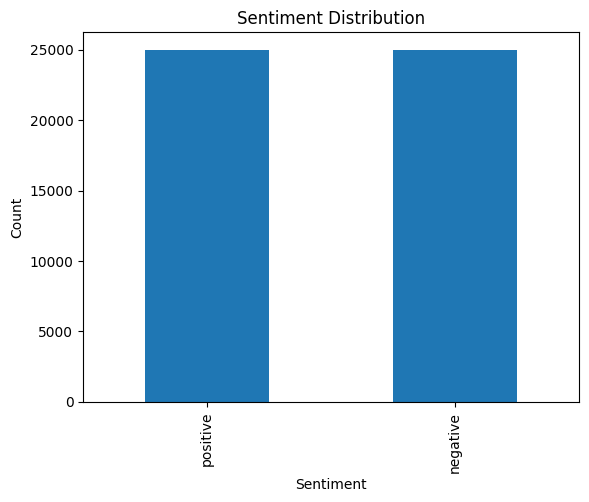

In [24]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [25]:
stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)               # remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)            # keep letters only
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    # remove stopwords
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df["clean_review"] = df["review"].astype(str).apply(clean_text)

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


In [26]:
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1})
df[["sentiment", "label"]].head(5)

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


## Train/Test Split

In [27]:
X = df["clean_review"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 40000
Test size: 10000


## TF-IDF Vectorization
### Difference between Bag-of-Words and TF-IDF
* Why limit features (speed + noise reduction)
* Why KNN needs numeric vectors

In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2) # performance booster
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40000, 5000)
X_test shape: (10000, 5000)


## Model: KNN

* What is K in KNN?
* Why cosine distance often works better for text
* How K affects bias/variance

In [29]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="cosine"   # better for TF-IDF text similarity
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7401

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.67      0.72      5000
           1       0.71      0.81      0.76      5000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



## Confusion Matrix (Evaluation)

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[3336, 1664],
       [ 935, 4065]])

plot

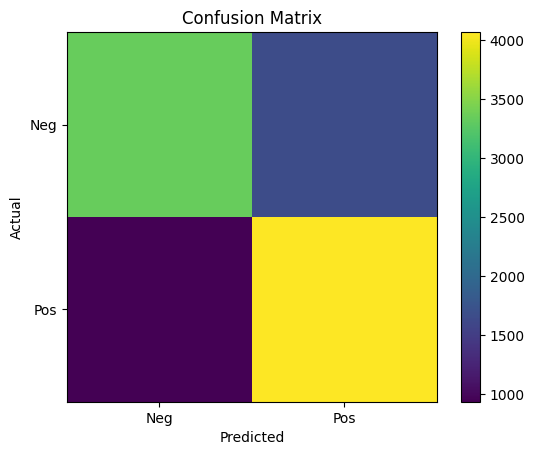

In [31]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Neg","Pos"])
plt.yticks([0,1], ["Neg","Pos"])
plt.colorbar()
plt.show()

### Hyperparameter Tuning: Try Different K Values

* K too small = noisy
* K too big = oversmoothing
* Choosing best K by validation performance


In [19]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results.append((k, acc))

results_df = pd.DataFrame(results, columns=["k", "accuracy"]).sort_values("accuracy", ascending=False)
results_df

,k,accuracy
6,15,0.7638
5,11,0.7556
4,9,0.7525
3,7,0.7474
2,5,0.7401
1,3,0.7280
0,1,0.7001


plot

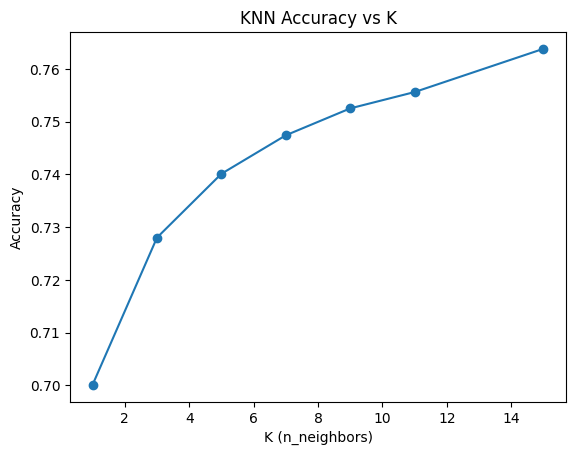

In [20]:
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.title("KNN Accuracy vs K")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.show()

## Sample Text Demo on Sentiment analysis

In [34]:
def predict_sentiment(text: str):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = knn.predict(vec)[0]
    return "positive" if pred == 1 else "negative"

print(predict_sentiment("This movie was absolutely amazing, I loved it."))
print(predict_sentiment("Terrible plot and boring acting."))
print(predict_sentiment("The plot was great I loved all of the characters"))
print(predict_sentiment("I hate this movie!!!!"))

positive
negative
positive
negative
